In [21]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from scipy.optimize import least_squares

sys.path.insert(0, str(Path("../../nogse_pipeline/src")))

import models.model_fitting as _mf
importlib.reload(_mf)
from models.model_fitting import M_pgse_free, M_pgse_rest

from plotting.publication.tc_param_vars import _roi_color_map, DEFAULT_BRAIN_MARKERS

In [22]:
MASTER_PATH         = Path("../../analysis/brains/ogse_experiments/master.long.parquet")
# Folder whose fit_results.xlsx supplies tc (and D0) for the PGSE check:
FIT_RESULTS_DIR     = Path("../../analysis/brains/ogse_experiments/lab/fit_tort-rest_global_norm-2")
OUT_DIR             = Path("../../analysis/brains/ogse_experiments/lab/fit_check_PGSE-2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS          = ["tra", "long"]
TD_LIST             = None    # None → all td; list of floats → e.g. [76.0, 90.0]
ROI_LIST            = ["AntCC", "MidAntCC", "CentralCC", "MidPostCC", "PostCC"]     # None → all ROIs; list of strings → e.g. ["WM", "GM"]
G_COLUMN            = "g_thorsten"
G_CORRECTION_COLUMN = "grad_correction_factor"  # None → no correction
Y_COLUMN            = "value_norm"               # "value" or "value_norm"

In [23]:
fit_params = pd.read_excel(FIT_RESULTS_DIR / "fit_results.xlsx")
fit_params["source_fit_results_path"] = str(FIT_RESULTS_DIR.resolve())

D0_FIXED = float(fit_params["D0_m2ms"].iloc[0])

def _make_lookup(cols, value_col):
    """Build a dict keyed by tuple(*cols) → value_col from the first unique row per key."""
    return (
        fit_params
        .drop_duplicates(cols)[cols + [value_col]]
        .set_index(cols)[value_col]
        .to_dict()
    )

# per (subj, roi, direction)
tc_lookup     = _make_lookup(["subj", "roi", "direction"], "tc_ms")
alpha_lookup  = _make_lookup(["subj", "roi", "direction"], "alpha")
alpha2_lookup = _make_lookup(["subj", "roi", "direction"], "alpha2")

# M0 varies per td_ms (same as RN), so key by (subj, roi, direction, td_ms)
M0_lookup = _make_lookup(["subj", "roi", "direction", "td_ms"], "M0")

# RN is shared across N in the source fit; keep it per (subj, roi, direction, td_ms)
# so each curve gets the RN that was actually used for that (direction, td) pair.
rn_lookup = _make_lookup(["subj", "roi", "direction", "td_ms"], "RN")

print(f"D0 from fit_results : {D0_FIXED:.3e} m²/ms")
print(f"Source              : {FIT_RESULTS_DIR.resolve()}")
print(f"tc/alpha entries    : {len(tc_lookup)} (subj, roi, direction) groups")
print(f"M0 entries          : {len(M0_lookup)} (subj, roi, direction, td_ms) groups")
print(f"RN entries          : {len(rn_lookup)} (subj, roi, direction, td_ms) groups")
fit_params[["subj", "roi", "direction", "tc_ms", "alpha", "alpha2", "D0_m2ms", "M0", "RN", "source_fit_results_path"]].drop_duplicates()

D0 from fit_results : 3.000e-12 m²/ms
Source              : /mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/analysis/brains/ogse_experiments/lab/fit_tort-rest_global_norm-2
tc/alpha entries    : 30 (subj, roi, direction) groups
M0 entries          : 130 (subj, roi, direction, td_ms) groups
RN entries          : 130 (subj, roi, direction, td_ms) groups


,subj,roi,direction,tc_ms,alpha,alpha2,D0_m2ms,M0,RN,source_fit_results_path
0,BRAIN,AntCC,long,1.384530,0,0.846559,3.000000e-12,2.773417e-01,32.831872,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
2,BRAIN,AntCC,long,1.384530,0,0.846559,3.000000e-12,1.625496e-01,0.003792,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
4,BRAIN,AntCC,long,1.384530,0,0.846559,3.000000e-12,2.221233e-01,8.796893,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
6,BRAIN,AntCC,long,1.384530,0,0.846559,3.000000e-12,4.624624e-02,40.377814,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
8,BRAIN,AntCC,long,1.384530,0,0.846559,3.000000e-12,5.310500e-36,37.413342,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
...,...,...,...,...,...,...,...,...,...,...
250,MBBL,PostCC,long,0.085007,0,0.890114,3.000000e-12,6.583650e-17,50.071685,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
252,MBBL,PostCC,tra,0.073966,0,0.897766,3.000000e-12,4.154238e-01,38.554780,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
254,MBBL,PostCC,tra,0.073966,0,0.897766,3.000000e-12,3.850828e-01,25.544066,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
256,MBBL,PostCC,tra,0.073966,0,0.897766,3.000000e-12,3.293769e-01,38.501783,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...


In [24]:
df = pd.read_parquet(MASTER_PATH)

data = df[
    (df.row_kind == "signal_rotated") &
    (df.direction.isin(DIRECTIONS)) &
    (df.N == 1) &
    (df.stat == "avg")
].copy()

missing_cols = [c for c in [G_COLUMN, Y_COLUMN, G_CORRECTION_COLUMN]
                if c is not None and c not in data.columns]
if missing_cols:
    raise KeyError(f"Missing column(s) in data: {missing_cols}")

data["G_fit"] = data[G_COLUMN]
if G_CORRECTION_COLUMN is not None:
    data["G_fit"] = data["G_fit"] * data[G_CORRECTION_COLUMN]
data["y_raw"] = data["value"]
data["y_fit"] = data[Y_COLUMN]

G_LABEL = f"Gradient G [mT/m] ({G_COLUMN})"
Y_LABEL = f"{Y_COLUMN} [a.u.]"

if TD_LIST is not None:
    data = data[data.td_ms.isin(TD_LIST)]
if ROI_LIST is not None:
    data = data[data.roi.isin(ROI_LIST)]

print(f"Rows loaded: {len(data)}")
print("Groups (subj, roi, dir):", data.groupby(["subj", "roi", "direction"]).ngroups)
print(f"Gradient: {G_COLUMN}" + (f" * {G_CORRECTION_COLUMN}" if G_CORRECTION_COLUMN else ""))
print(f"Signal  : {Y_COLUMN}")
data[["subj", "roi", "direction", "td_ms", "N", "G_fit", "y_fit"]]

Rows loaded: 1430
Groups (subj, roi, dir): 30
Gradient: g_thorsten * grad_correction_factor
Signal  : value_norm


,subj,roi,direction,td_ms,N,G_fit,y_fit
2376,BRAIN,AntCC,tra,90.0,1,0.000000,1.000000
2377,BRAIN,AntCC,tra,90.0,1,2.139139,0.902029
2378,BRAIN,AntCC,tra,90.0,1,4.278277,0.802715
2379,BRAIN,AntCC,tra,90.0,1,6.417416,0.724720
2380,BRAIN,AntCC,tra,90.0,1,8.556554,0.630698
...,...,...,...,...,...,...,...
173707,MBBL,PostCC,long,210.0,1,3.615557,0.376999
173708,MBBL,PostCC,long,210.0,1,4.218150,0.377236
173709,MBBL,PostCC,long,210.0,1,4.820743,0.366841
173710,MBBL,PostCC,long,210.0,1,5.423336,0.327010


In [25]:
def _predict(td, G, M0, tc, alpha2, rn, S0):
    """
    PGSE mixed model:
      M0 * M_pgse_rest(td, G, tc, 1, D0)  +  (1-M0) * M_pgse_free(td, G, 1, alpha2, D0)
    plus Rician noise floor normalised by S0 (raw signal at G≈0).
    tc, alpha2, rn, M0 and D0 are all fixed from fit_params.
    """
    with np.errstate(over="ignore", invalid="ignore"):
        signal = (
            M0       * M_pgse_rest(td, G, tc,    1, D0_FIXED)
            + (1-M0) * M_pgse_free(td, G, 1, alpha2, D0_FIXED)
        )
        return np.sqrt(signal**2 + (rn / S0)**2)


def fit_group(group_df, subj, roi):
    """
    For each (td, direction) at N=1, evaluate the PGSE mixed model using all
    parameters fixed from fit_params (tc, alpha2, M0, RN, D0).
    """
    directions_present = sorted(group_df.direction.unique())
    tds = sorted(float(t) for t in group_df.td_ms.unique())

    curves = []
    for direction in directions_present:
        dir_df = group_df[group_df.direction == direction]
        for td in tds:
            sub = dir_df[np.isclose(dir_df.td_ms.astype(float), td)].sort_values("G_fit")
            if sub.empty:
                continue
            s0_raw = float(sub.loc[sub.G_fit.abs() == sub.G_fit.abs().min(), "y_raw"].iloc[0])
            curves.append(dict(
                td=td, N=1, direction=direction,
                G=sub.G_fit.values, y=sub.y_fit.values, S0=s0_raw,
            ))

    rows_out   = []
    curve_fits = {}

    for c in curves:
        direction = c["direction"]
        td        = c["td"]
        key_dir   = (subj, roi, direction)
        key_td    = (subj, roi, direction, td)
        if key_dir not in tc_lookup:
            print(f"  WARNING: no tc entry for {key_dir}, skipping curve.")
            continue
        tc     = float(tc_lookup[key_dir])
        alpha  = float(alpha_lookup.get(key_dir, float("nan")))
        alpha2 = float(alpha2_lookup.get(key_dir, float("nan")))
        M0     = float(M0_lookup.get(key_td, float("nan")))
        rn     = float(rn_lookup.get(key_td, float("nan")))

        rn_safe     = rn     if np.isfinite(rn)     else 0.0
        alpha2_safe = alpha2 if np.isfinite(alpha2) else 1.0
        M0_safe     = M0     if np.isfinite(M0)     else 0.5

        def make_residuals(c_=c, td_=td, tc_=tc, alpha2_=alpha2_safe, M0_=M0_safe,
                           rn_=rn_safe, s0_=c["S0"]):
            def residuals(params):
                y_hat = _predict(td_, c_["G"], M0_, tc_, alpha2_, rn_, s0_)
                out = y_hat - c_["y"]
                return np.where(np.isfinite(out), out, 1e6)
            return residuals

        i0 = int(np.argmin(np.abs(c["G"])))
        x0 = [float(c["y"][i0])]
        result = least_squares(make_residuals(), x0, bounds=([0.0], [1.0]),
                               method="trf", max_nfev=1000)

        curve_fits[(td, direction)] = dict(
            M0=M0, tc=tc, alpha=alpha, alpha2=alpha2_safe, rn=rn_safe,
            cost=float(result.cost), success=bool(result.success),
        )
        rows_out.append(dict(
            subj=subj, roi=roi, direction=direction,
            td_ms=td, N=1,
            tc_ms=tc,
            alpha=alpha,
            alpha2=alpha2,
            RN=rn,
            D0_m2ms=D0_FIXED,
            M0=M0,
            g_column=G_COLUMN,
            g_correction_column=G_CORRECTION_COLUMN,
            y_column=Y_COLUMN,
            cost=float(result.cost),
            success=bool(result.success),
            source_fit_results_path=str(FIT_RESULTS_DIR.resolve()),
        ))

    return rows_out, curves, curve_fits

In [26]:
all_rows  = []
fit_store = {}

for (subj, roi), grp in data.groupby(["subj", "roi"]):
    print(f"{subj:6s}  {roi:25s} ...", end="  ")
    rows_out, curves, curve_fits = fit_group(grp, subj, roi)
    all_rows.extend(rows_out)
    fit_store[(subj, roi)] = dict(curves=curves, curve_fits=curve_fits)
    for direction in sorted(set(c["direction"] for c in curves)):
        cfs = [cf for (td_, dir_), cf in curve_fits.items() if dir_ == direction]
        if cfs:
            tc_val = cfs[0]["tc"]
            M0s    = [cf["M0"] for cf in cfs]
            print(f"{direction}: tc={tc_val:.3f} ms  M0_mean={np.mean(M0s):.3f}", end="  ")
    print()

BRAIN   AntCC                     ...  long: tc=1.385 ms  M0_mean=0.142  tra: tc=0.593 ms  M0_mean=0.333  
BRAIN   CentralCC                 ...  long: tc=0.129 ms  M0_mean=0.091  tra: tc=0.074 ms  M0_mean=0.236  
BRAIN   MidAntCC                  ...  long: tc=0.074 ms  M0_mean=0.149  tra: tc=1.066 ms  M0_mean=0.300  
BRAIN   MidPostCC                 ...  long: tc=0.111 ms  M0_mean=0.062  tra: tc=0.074 ms  M0_mean=0.247  
BRAIN   PostCC                    ...  long: tc=0.074 ms  M0_mean=0.113  tra: tc=0.095 ms  M0_mean=0.401  
LUDG    AntCC                     ...  long: tc=0.165 ms  M0_mean=0.103  tra: tc=0.074 ms  M0_mean=0.264  
LUDG    CentralCC                 ...  long: tc=0.074 ms  M0_mean=0.066  tra: tc=1.242 ms  M0_mean=0.276  
LUDG    MidAntCC                  ...  long: tc=1.045 ms  M0_mean=0.095  tra: tc=0.074 ms  M0_mean=0.240  
LUDG    MidPostCC                 ...  long: tc=0.235 ms  M0_mean=0.070  tra: tc=0.861 ms  M0_mean=0.192  
LUDG    PostCC                    ...

In [27]:
results_df = pd.DataFrame(all_rows)
results_df.to_excel(OUT_DIR / "fit_results.xlsx", index=False)
print(f"Saved {len(results_df)} rows to {OUT_DIR / 'fit_results.xlsx'}")
results_df

Saved 130 rows to ../../analysis/brains/ogse_experiments/lab/fit_check_PGSE-2/fit_results.xlsx


,subj,roi,direction,td_ms,N,tc_ms,alpha,alpha2,RN,D0_m2ms,M0,g_column,g_correction_column,y_column,cost,success,source_fit_results_path
0,BRAIN,AntCC,long,76.0,1,1.384530,0.0,0.846559,32.831872,3.000000e-12,2.773417e-01,g_thorsten,grad_correction_factor,value_norm,0.050845,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
1,BRAIN,AntCC,long,90.0,1,1.384530,0.0,0.846559,0.003792,3.000000e-12,1.625496e-01,g_thorsten,grad_correction_factor,value_norm,0.018575,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
2,BRAIN,AntCC,long,120.0,1,1.384530,0.0,0.846559,8.796893,3.000000e-12,2.221233e-01,g_thorsten,grad_correction_factor,value_norm,0.043969,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
3,BRAIN,AntCC,long,143.4,1,1.384530,0.0,0.846559,40.377814,3.000000e-12,4.624624e-02,g_thorsten,grad_correction_factor,value_norm,0.047957,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
4,BRAIN,AntCC,long,210.0,1,1.384530,0.0,0.846559,37.413342,3.000000e-12,5.310500e-36,g_thorsten,grad_correction_factor,value_norm,0.114895,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,MBBL,PostCC,long,210.0,1,0.085007,0.0,0.890114,50.071685,3.000000e-12,6.583650e-17,g_thorsten,grad_correction_factor,value_norm,0.009335,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
126,MBBL,PostCC,tra,90.0,1,0.073966,0.0,0.897766,38.554780,3.000000e-12,4.154238e-01,g_thorsten,grad_correction_factor,value_norm,0.003342,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
127,MBBL,PostCC,tra,120.0,1,0.073966,0.0,0.897766,25.544066,3.000000e-12,3.850828e-01,g_thorsten,grad_correction_factor,value_norm,0.008540,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
128,MBBL,PostCC,tra,143.4,1,0.073966,0.0,0.897766,38.501783,3.000000e-12,3.293769e-01,g_thorsten,grad_correction_factor,value_norm,0.013014,True,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...


In [28]:
G_plot = np.linspace(0, float(data.G_fit.max()), 300)

for (subj, roi), store in fit_store.items():
    curves      = store["curves"]
    curve_fits  = store["curve_fits"]
    dirs_present = sorted(set(c["direction"] for c in curves))

    for direction in dirs_present:
        dir_curves = [c for c in curves if c["direction"] == direction]
        td_list    = sorted(set(c["td"] for c in dir_curves))

        fig, axes = plt.subplots(1, len(td_list), figsize=(4 * len(td_list), 3.5), sharey=True)
        axes = np.atleast_1d(axes)

        for ax, td in zip(axes, td_list):
            c  = next((x for x in dir_curves if x["td"] == td), None)
            cf = curve_fits.get((td, direction))
            if c is None or cf is None:
                continue
            M0     = cf["M0"]
            tc     = cf["tc"]
            alpha2 = cf["alpha2"]
            rn     = cf["rn"]
            ax.scatter(c["G"], c["y"], color="C0", s=20, zorder=3, label="N=1 data")
            y_hat = _predict(td, G_plot, M0, tc, alpha2, rn, c["S0"])
            ax.plot(G_plot, y_hat, color="C0", label="PGSE fit (N=1)")
            ax.set_title(
                f"td = {td:.1f} ms\ntc={tc:.2f} ms  M0={M0:.3f}  cost={cf['cost']:.2e}",
                fontsize=7
            )
            ax.set_xlabel(G_LABEL)
            ax.set_xlim(0,25)
            ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)

        axes[0].set_ylabel(Y_LABEL)
        axes[0].legend(fontsize=6)
        fig.suptitle(f"{subj}  |  {roi}  |  {direction}", fontsize=9)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"fit_{subj}_{roi}_{direction}.png", dpi=120)
        plt.close(fig)

print("Fit plots saved.")

Fit plots saved.


In [29]:
for (subj, roi), store in fit_store.items():
    curves      = store["curves"]
    curve_fits  = store["curve_fits"]
    dirs_present = sorted(set(c["direction"] for c in curves))

    for direction in dirs_present:
        dir_curves = [c for c in curves if c["direction"] == direction]
        td_list    = sorted(set(c["td"] for c in dir_curves))
        tc_dir     = curve_fits.get((td_list[0], direction), {}).get("tc", 0) if td_list else 0

        fig, axes = plt.subplots(1, len(td_list), figsize=(4 * len(td_list), 3.5), sharey=True)
        axes = np.atleast_1d(axes)

        for ax, td in zip(axes, td_list):
            c  = next((x for x in dir_curves if x["td"] == td), None)
            cf = curve_fits.get((td, direction))
            if c is None or cf is None:
                continue
            M0     = cf["M0"]
            tc     = cf["tc"]
            alpha2 = cf["alpha2"]
            rn     = cf["rn"]
            ax.scatter(c["G"], c["y"], color="C0", s=20, zorder=3, label="N=1 data")
            y_hat = _predict(td, G_plot, M0, tc, alpha2, rn, c["S0"])
            ax.plot(G_plot, y_hat, color="C0", label="PGSE fit (N=1)")
            ax.set_title(f"td = {td:.1f} ms", fontsize=8)
            ax.set_xlabel(G_LABEL)
            ax.set_yscale("log")
            ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)
            ax.set_xlim(0,25)


        axes[0].set_ylabel(f"{Y_COLUMN} [a.u.] (log)")
        axes[0].legend(fontsize=6)
        fig.suptitle(
            f"{subj}  |  {roi}  |  {direction}  |  tc={tc_dir:.2f} ms",
            fontsize=9
        )
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"fit_norm_{subj}_{roi}_{direction}.png", dpi=120)
        plt.close(fig)

print("Log-scale fit plots saved.")

Log-scale fit plots saved.


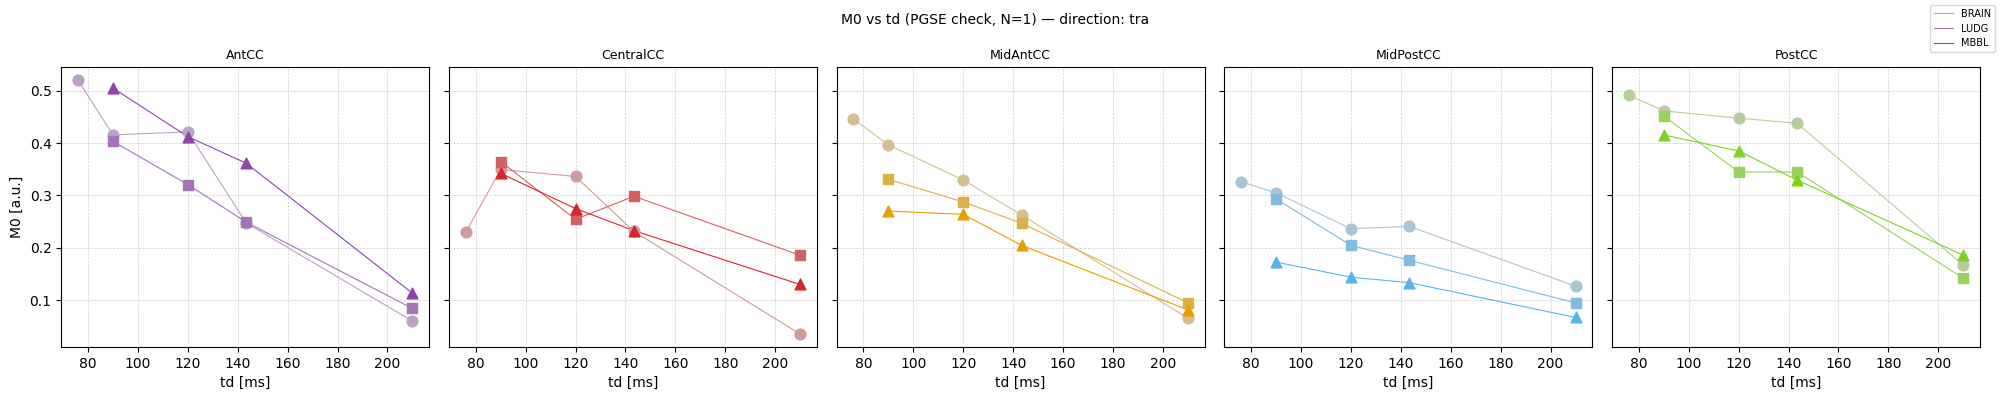

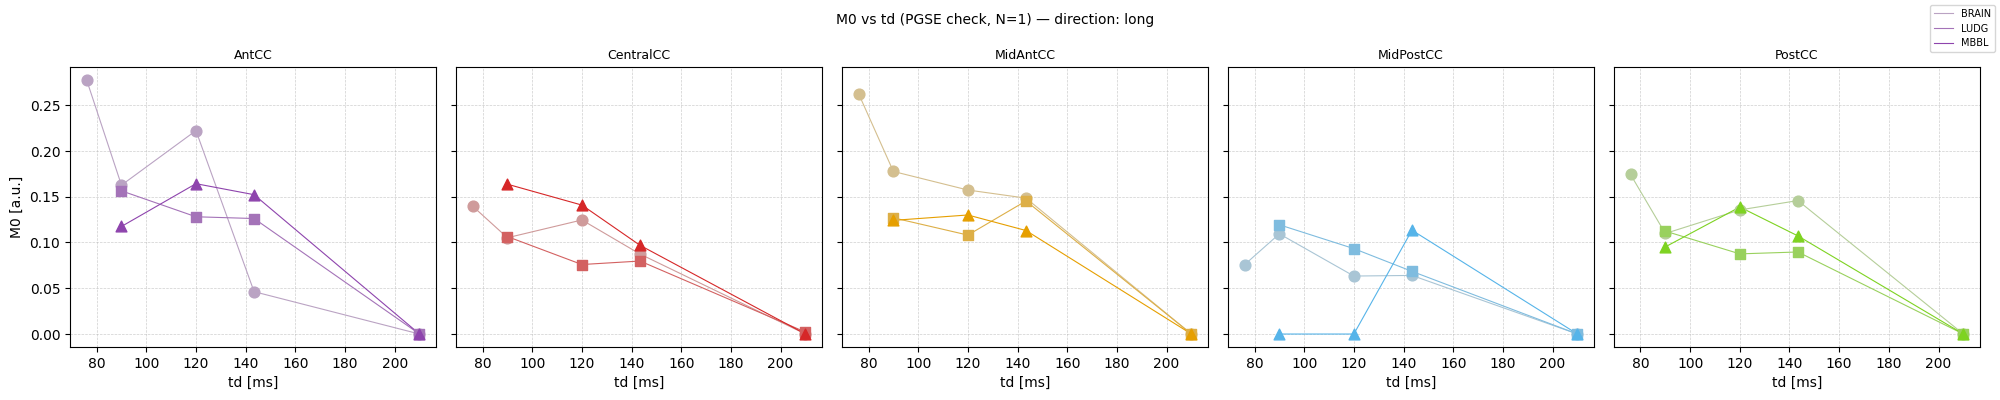

In [31]:
rois_plot     = sorted(results_df.roi.unique())
subjects_plot = sorted(results_df.subj.unique())
roi_colors    = _roi_color_map(rois_plot)

for direction in DIRECTIONS:
    sub = results_df[results_df.direction == direction]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, len(rois_plot), figsize=(4 * len(rois_plot), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, roi in zip(axes, rois_plot):
        base_color = roi_colors[roi]
        cmap = mcolors.LinearSegmentedColormap.from_list("", ["#cccccc", base_color])
        for i, subj in enumerate(subjects_plot):
            shade  = cmap(0.3 + 0.7 * i / max(1, len(subjects_plot) - 1))
            marker = DEFAULT_BRAIN_MARKERS[i % len(DEFAULT_BRAIN_MARKERS)]
            g = (
                sub[(sub.roi == roi) & (sub.subj == subj)]
                .drop_duplicates("td_ms")
                .sort_values("td_ms")
            )
            if g.empty:
                continue
            ax.scatter(g.td_ms, g["M0"], color=shade, marker=marker, s=60, zorder=3)
            ax.plot(g.td_ms, g["M0"], color=shade, linewidth=0.8, label=subj)
        ax.set_title(roi, fontsize=9)
        ax.set_xlabel("td [ms]")
        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    axes[0].set_ylabel("M0 [a.u.]")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, fontsize=7, loc="upper right", ncol=1)
    fig.suptitle(f"M0 vs td (PGSE check, N=1) — direction: {direction}", fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"M0_vs_td_{direction}.png", dpi=120)
    plt.show()